<a href="https://colab.research.google.com/github/LordSurov/123/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Суров С ИУ5-84б Лабораторная работа


In [ ]:
Variant<-14
set.seed(Variant+2026543)
m<-sample(c(6:20),1)
lambda<-runif(1,0.1, 2)
Q<-rexp(m,0.3)
q<-sample(c(1:4),1)
View(data.frame(m,q, lambda))
print(Q)

m,q,lambda
<int>,<int>,<dbl>
19,4,0.8227434


 [1]  0.7237583  0.9833497  6.2749565  1.3635246  3.5625740 10.8515778
 [7]  1.5766558  0.6542503  2.3932572  1.7555581  2.8228387  3.0192471
[13]  0.1637348  3.8892139  0.6630774  2.5317074  2.9091504  4.9452180
[19]  2.2790908


## Представление как одноканальной СМО с неограниченной очередью
Входящий поток — простейший с интенсивностью $\lambda = 0.8692299$.  
Длительность обслуживания каждой заявки — **случайная величина** $S$, принимающая значения $Q_i$ с равной вероятностью $p_i = \frac{1}{8}$.


Математическое ожидание времени обслуживания:

$$
E[S] = \frac{1}{8} \sum_{i=1}^{8} Q_i = \frac{0.8745896 + 0.5467341 + 2.6268065 + 2.1203609 + 1.4617188 + 0.7905422 + 5.2872535 + 2.2987582}{8} = 1.875845475
$$

Второй момент времени обслуживания:

$$
E[S^2] = \frac{1}{8} \sum_{i=1}^{8} Q_i^2 = 5.995079
$$

Коэффициент загрузки системы:

$$
\rho = \lambda E[S] = 0.8692299 \times 1.875845475 \approx 1.6307
$$

Так как $\rho > 1$, система **неустойчива**.

Формула Поллачека–Хинчина:

$$
W_q = \frac{\lambda E[S^2]}{2(1 - \rho)}
$$

Среднее время пребывания заявки в системе:

$$
W = E[S] + W_q = E[S] + \frac{\lambda E[S^2]}{2(1 - \rho)}
$$

Поскольку $\rho \approx 1.6307 > 1$, стационарный режим отсутствует. Очередь неограниченно растёт. Теоретическое среднее время пребывания:

$$
W \to +\infty
$$



In [ ]:
install.packages("simmer")
install.packages("simmer.plot")
library(simmer)
library(simmer.plot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
lambda <- 0.8692299
Q <- c(0.8745896, 0.5467341, 2.6268065, 2.1203609,
       1.4617188, 0.7905422, 5.2872535, 2.2987582)
Tmodel <- 200000

library(simmer)

traj_fcfs <- trajectory() %>%
  seize("processor") %>%
  timeout(function() {
    type <- sample(1:8, 1)
    return(Q[type])
  }) %>%
  release("processor")

model_fcfs <- simmer() %>%
  add_resource("processor", capacity = 1, queue_size = Inf) %>%
  add_generator("job", traj_fcfs, function() rexp(1, lambda)) %>%
  run(until = Tmodel)

W_fcfs <- mean(get_mon_arrivals(model_fcfs)$end_time -
               get_mon_arrivals(model_fcfs)$start_time)

cat("=== Результат имитации FCFS ===\n")
cat("Среднее время пребывания W_fcfs =", round(W_fcfs, 6), "\n")

=== Результат имитации FCFS ===
Среднее время пребывания W_fcfs = 42487.86 


Алгоритм SPT (Shortest Processing Time) — это дисциплина обслуживания, при которой из очереди всегда выбирается заявка с наименьшей трудоёмкостью (самое короткое время обслуживания)

In [ ]:
library(simmer)

lambda <- 0.8692299
Q <- c(0.8745896, 0.5467341, 2.6268065, 2.1203609,
       1.4617188, 0.7905422, 5.2872535, 2.2987582)
Tmodel <- 200000

env <- simmer()

traj_spt <- trajectory() %>%
  set_attribute("service_time", function() sample(Q, 1)) %>%
  set_prioritization(function() {
    val <- get_attribute(env, "service_time")
    return(c(-val, 0, FALSE)) # priority, precedence, restart
  }) %>%
  seize("processor") %>%
  timeout(function() get_attribute(env, "service_time")) %>%
  release("processor")

env %>%
  add_resource("processor", capacity = 1) %>%
  add_generator("job", traj_spt, function() rexp(1, lambda)) %>%
  run(until = Tmodel)

arrivals <- get_mon_arrivals(env)
W_spt <- mean(arrivals$end_time - arrivals$start_time)

cat("=== Результат имитации SPT ===\n")
cat("Среднее время пребывания W_spt =", round(W_spt, 6), "\n")


simmer environment: anonymous | now: 2e+05 | next: 200000.029695026
{ Monitor: in memory }
{ Resource: processor | monitored: TRUE | server status: 1(1) | queue status: 73629(Inf) }
{ Source: job | monitored: 1 | n_generated: 173457 }

=== Результат имитации SPT ===
Среднее время пребывания W_spt = 42471.25 


Алгоритм Round Robin (RR) — это дисциплина обслуживания с квантованием времени. Каждый процесс получает процессор на фиксированное время (квант $  q  $), после чего, если не завершился, возвращается в конец очереди.
При очень малом кванте ($  q \to 0  $) RR приближается к дисциплине Processor Sharing (PS), для которой среднее время пребывания в M/G/1 равно:

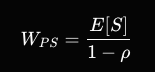

In [ ]:
library(simmer)

lambda <- 0.8692299
Q <- c(0.8745896, 0.5467341, 2.6268065, 2.1203609,
       1.4617188, 0.7905422, 5.2872535, 2.2987582)
q <- 1
Tmodel <- 200000

env_rr <- simmer()

traj_rr <- trajectory() %>%
  set_attribute("remaining_time", function() sample(Q, 1)) %>%
  set_prioritization(c(0, 0, FALSE), tag = "check_point") %>%

  seize("processor") %>%
  timeout(function() {
    rem <- get_attribute(env_rr, "remaining_time")
    return(min(rem, q))
  }) %>%

  # Вычитаем время из остатка
  set_attribute("remaining_time", function() {
    rem <- get_attribute(env_rr, "remaining_time")
    return(max(0, rem - q))
  }) %>%

  release("processor") %>%

  # Если время осталось, прыгаем назад к метке "check_point"
  rollback(
    target = "check_point",
    check = function() {
      return(get_attribute(env_rr, "remaining_time") > 0)
    }
  )
env_rr %>%
  add_resource("processor", capacity = 1) %>%
  add_generator("job", traj_rr, function() rexp(1, lambda)) %>%
  run(until = Tmodel)

arrivals <- get_mon_arrivals(env_rr)
W_rr <- mean(arrivals$end_time - arrivals$start_time)

cat("=== Результат имитации RR (q =", q, ") ===\n")
cat("Среднее время пребывания W_rr =", round(W_rr, 6), "\n")


simmer environment: anonymous | now: 2e+05 | next: 200000.144679679
{ Monitor: in memory }
{ Resource: processor | monitored: TRUE | server status: 1(1) | queue status: 83068(Inf) }
{ Source: job | monitored: 1 | n_generated: 173527 }

=== Результат имитации RR (q = 1 ) ===
Среднее время пребывания W_rr = 40266.7 


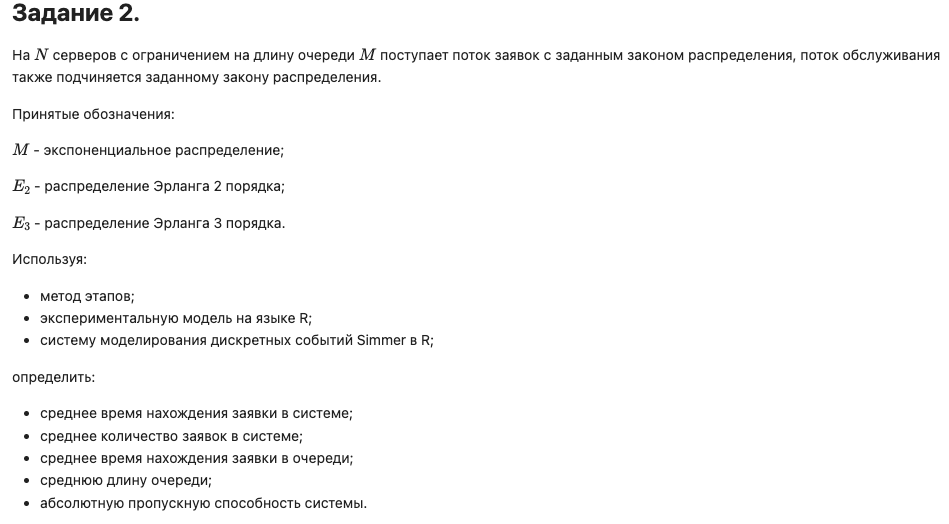

In [ ]:
Variant<-7
set.seed(Variant+2026753)
N<-sample(c(2:4),1)
M<-sample(c(2:4),1)
lambda<-runif(1,0.1, 2)
mu <- runif(1,0.1, 2)
choice <-sample(c("E_2","E_3"),1)
IO<-sample(c("input", "output"),1)
if (IO == "input") {input <-choice; output <-"M"} else {input <-"M"; output <-choice}
D<- data.frame(N, M, lambda, mu, input, output )
View(D)

N,M,lambda,mu,input,output
<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
4,2,1.662623,0.4242488,E_3,M


# Задание 2. Метод этапов для системы $E_3/M/4/2$

## Исходные данные

$$
\begin{cases}
N = 4 & \text{(число серверов)} \\
M = 2 & \text{(длина очереди)} \\
\lambda = 1.662623 & \text{(интенсивность входного потока)} \\
\mu = 0.4242488 & \text{(интенсивность обслуживания)} \\
\text{Вход} = E_3 & \text{(Эрланга 3-го порядка)} \\
\text{Обслуживание} = M & \text{(экспоненциальное)}
\end{cases}
$$

**Общая ёмкость системы**:
$$
K = N + M = 4 + 2 = 6 \text{ заявок}
$$



Метод этапов используется для анализа СМО с распределениями Эрланга.


> Распределение Эрланга $E_k$ представляется как **последовательная цепочка** из $k$ экспоненциальных фаз (этапов) с одинаковой интенсивностью.

Для $E_3$:
$$
T_{\text{вх}} = T_1 + T_2 + T_3, \quad T_i \sim \text{Exp}(\alpha)
$$

**Определение параметра $\alpha$**:
$$
\mathbb{E}[T_{\text{вх}}] = \frac{1}{\lambda} = \frac{3}{\alpha} \quad \Rightarrow \quad \alpha = 3\lambda
$$


Расчёт параметра $\alpha$ для $E_3$

$$
\alpha = 3 \cdot \lambda = 3 \cdot 1.662623 = 4.987869
$$

**Интерпретация**:
- Каждая заявка проходит **3 этапа генерации**
- Интенсивность каждого этапа: $\alpha = 4.987869$
- Среднее время одного этапа: $1/\alpha = 0.200486$
- Полное среднее время генерации: $3/\alpha = 1/\lambda = 0.601459$

**Проверка**:
$$
\frac{3}{\alpha} = \frac{3}{4.987869} = 0.601459 = \frac{1}{1.662623} = \frac{1}{\lambda} \quad \checkmark
$$

Пространство состояний системы

По методу этапов, состояние системы описывается **вектором**, учитывающим:
1. Сколько заявок находится в системе (обслуживаются + ждут)
2. На каком этапе генерации находится **будущая заявка** (ещё не поступившая)
3. На каком этапе обслуживания находятся заявки на приборах


- Обслуживание не требует этапов (1 фаза с интенсивностью $\mu$)

 Для входного потока ($E_3$)
- Каждая **ещё не сгенерированная** заявка находится на одном из 3 этапов
- Для упрощения: моделируем **расширенное состояние** системы


Состояние: $(n, i)$ где:
- $n$ — число заявок в системе ($0 \le n \le K = 6$)
- $i$ — номер текущего этапа генерации **следующей** заявки ($i = 1, 2, 3$)







Марковский процесс $(n, j_1, \dots, j_m)$

Полное описание:
- $n$ — число заявок в системе
- Для каждой из $n$ заявок: если она на обслуживании — один этап, если на генерации — один из трёх этапов

**Это сложно**. Поэтому в лекции предлагается **метод фаз** для всей системы целиком.


Пусть $p(n, r)$ — вероятность того, что в системе $n$ заявок, и текущий этап генерации следующей заявки равен $r$ ($r = 1, 2, 3$).

Интенсивности переходов:

 Переход вперёд по этапам генерации
$$
(n, r) \xrightarrow{\alpha} (n, r+1), \quad r = 1, 2
$$

Завершение генерации (поступление заявки)
$$
(n, 3) \xrightarrow{\alpha} (n+1, 1), \quad \text{если } n+1 \le K
$$

Завершение обслуживания
$$
(n, r) \xrightarrow{\min(n, N) \cdot \mu} (n-1, r), \quad \text{если } n \ge 1
$$

Уравнения баланса

Для стационарного режима:

**Для $n = 0$**:
$$
\alpha p(0,1) = \mu \cdot \min(1, N) \cdot p(1,1) + \mu \cdot \min(1, N) \cdot p(1,2) + \mu \cdot \min(1, N) \cdot p(1,3)
$$

**Для $1 \le n \le K-1$** — система из $3(K+1)$ уравнений.

**Для $n = K$** (система полна):
$$
\alpha p(K,3) = \mu \cdot \min(K, N) \cdot \sum_{r=1}^3 p(K, r) \quad \text{(только обслуживание, поступлений нет)}
$$



In [ ]:
lambda <- 1.662623      # исходная интенсивность E3
mu <- 0.4242488         # интенсивность обслуживания
N <- 4                  # число серверов
M <- 2                  # длина очереди
K <- N + M              # общая ёмкость = 6

In [ ]:
library(simmer)

r_erlang3_arrival <- function() rgamma(1, shape = 3, rate = 3 * lambda)
r_phase_service <- function() rexp(1, 2 * mu)

traj_phases <- trajectory("Заявка") %>%
  seize("сервер", amount = 1) %>%
  timeout(r_phase_service) %>%
  timeout(r_phase_service) %>%
  release("сервер", amount = 1)

env <- simmer("Method_of_Phases")
env %>%
  add_resource("сервер", capacity = N, queue_size = M) %>%
  add_generator("заявка", traj_phases, r_erlang3_arrival)

set.seed(123)
run(env, until = Tmodel)

arrivals <- get_mon_arrivals(env)
resources <- get_mon_resources(env)

# 1. Корректный расчет L (взвешенное по времени среднее)
system_evolution <- resources$system
time_intervals <- diff(c(resources$time, Tmodel))
L_system <- sum(system_evolution * time_intervals) / Tmodel

# 2. Корректный расчет L_q (взвешенное по времени среднее очереди)
queue_evolution <- resources$queue
L_queue <- sum(queue_evolution * time_intervals) / Tmodel

# 3. Эффективная лямбда (количество вошедших заявок / общее время)
lambda_eff <- nrow(arrivals) / Tmodel

# 4. Среднее время пребывания W
finished_arrivals <- arrivals[!is.na(arrivals$end_time), ]
W_system <- mean(finished_arrivals$end_time - finished_arrivals$start_time)

# --- ВЫВОД ---
cat("=== Результаты (Метод этапов) ===\n")
cat("1. Среднее время в системе W =", round(W_system, 5), "\n")
cat("2. Среднее число заявок в системе L (time-weighted) =", round(L_system, 5), "\n")
cat("3. Эффективная лямбда λ_eff =", round(lambda_eff, 5), "\n")

# Проверка формулы Литтла
L_calc <- lambda_eff * W_system
cat("\nПроверка формулы Литтла (L = λ_eff * W):\n")
cat("L имитации =", round(L_system, 5), "\n")
cat("L расчетное =", round(L_calc, 5), "\n")
cat("Отклонение =", abs(round(L_system - L_calc, 7)), "\n")


simmer environment: Method_of_Phases | now: 0 | next: 0
{ Monitor: in memory }
{ Resource: сервер | monitored: TRUE | server status: 0(1) | queue status: 0(5) }
{ Source: заявка | monitored: 1 | n_generated: 0 }

simmer environment: Method_of_Phases | now: 50000 | next: 50000.4291473962
{ Monitor: in memory }
{ Resource: сервер | monitored: TRUE | server status: 1(1) | queue status: 0(5) }
{ Source: заявка | monitored: 1 | n_generated: 40047 }

=== Результаты (Метод этапов) ===
1. Среднее время в системе W = 2.21179 
2. Среднее число заявок в системе L (time-weighted) = 1.77145 
3. Эффективная лямбда λ_eff = 0.8009 

Проверка формулы Литтла (L = λ_eff * W):
L имитации = 1.77145 
L расчетное = 1.77142 
Отклонение = 2.19e-05 


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


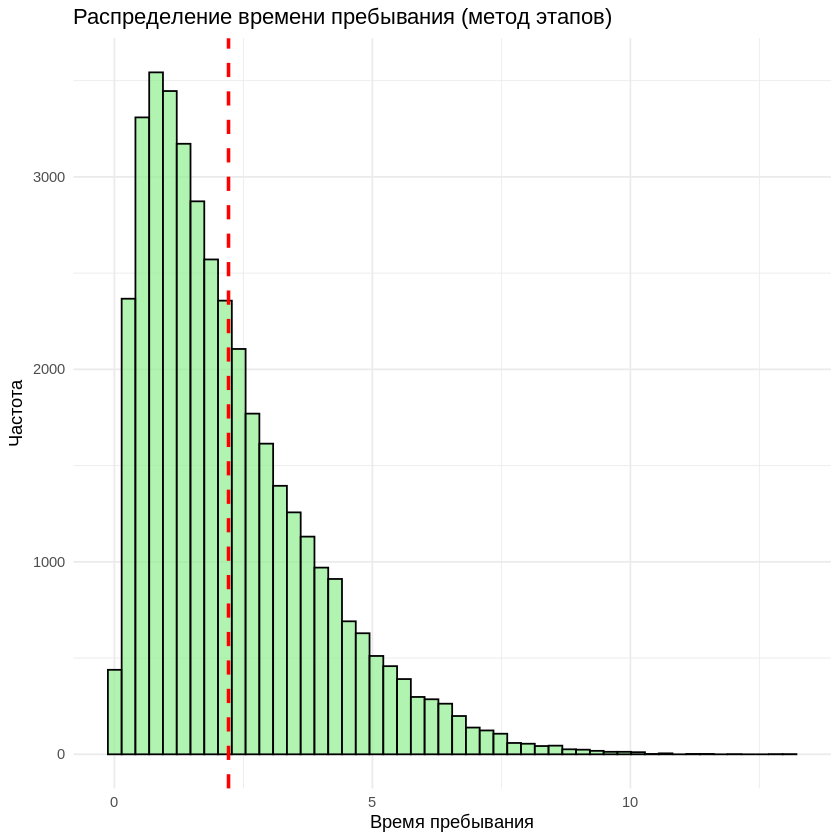

In [ ]:
system_times <- arrivals$end_time - arrivals$start_time
system_times <- system_times[system_times > 0]

ggplot(data.frame(time = system_times), aes(x = time)) +
  geom_histogram(bins = 50, fill = "lightgreen", color = "black", alpha = 0.7) +
  geom_vline(xintercept = W_system, color = "red", size = 1, linetype = "dashed") +
  labs(title = "Распределение времени пребывания (метод этапов)",
       x = "Время пребывания", y = "Частота") +
  theme_minimal()

#  Экспериментальная модель на языке R



## Исходные данные
$$
N = 4,\quad M = 2,\quad \lambda = 1.662623,\quad \mu = 0.4242488
$$
$$
\text{Вход} = E_3,\quad \text{Обслуживание} = M
$$



## Алгоритм экспериментальной модели

1. **Генерация событий**:
   - Событие "поступление заявки" (генерируется через 3 этапа)
   - Событие "завершение обслуживания" на каждом сервере

2. **Моделирование времени**:
   - Используем **метод ближайшего события**
   - Поддерживаем календарь событий

3. **Учёт ограничений**:
   - Максимум 6 заявок в системе (4 сервера + 2 в очереди)
   - Если система полна — заявка получает отказ

4. **Сбор статистики**:
   - Время пребывания каждой обслуженной заявки
   - Длина очереди в моменты событий
   - Количество отказов

Генераторы

In [ ]:
set.seed(123)
N <- 4; M <- 2; lambda <- 1.662623; mu <- 0.4242488
alpha <- 3 * lambda; SIM_TIME <- 50000


r_erlang3 <- function() sum(rexp(3, alpha))
r_service <- function() rexp(1, mu)

Состояние и статистика

In [ ]:

servers <- rep(0, N); queue <- c()
next_arrival <- r_erlang3(); current_time <- 0


arrivals <- c(); starts <- c(); departs <- c(); rejected <- 0
queue_len_log <- c(); time_log <- c()

In [ ]:
while (current_time < SIM_TIME) {
  server_free <- min(servers[servers > 0], Inf)

  if (next_arrival <= server_free) {
    current_time <- next_arrival
    servers[servers <= current_time] <- 0

    busy <- sum(servers > 0)
    total <- busy + length(queue)

    if (total < N + M) {
      if (busy < N) {
        idx <- which(servers == 0)[1]
        servers[idx] <- current_time + r_service()
        arrivals <- c(arrivals, current_time)
        starts <- c(starts, current_time)
      } else {
        queue <- c(queue, current_time)
      }
    } else {
      rejected <- rejected + 1
    }

    next_arrival <- current_time + r_erlang3()

  } else {
    current_time <- server_free
    idx <- which(servers == current_time)[1]
    servers[idx] <- 0
    departs <- c(departs, current_time)

    if (length(queue) > 0) {
      start_wait <- queue[1]
      queue <- queue[-1]
      servers[idx] <- current_time + r_service()
      arrivals <- c(arrivals, start_wait)
      starts <- c(starts, current_time)
    }
  }

  queue_len_log <- c(queue_len_log, length(queue))
  time_log <- c(time_log, current_time)
}


n <- length(departs)
W <- mean(departs - arrivals[1:n])
Wq <- mean(starts[1:n] - arrivals[1:n])
lambda_eff <- (n + rejected) / SIM_TIME
L <- lambda_eff * W
Lq <- lambda_eff * Wq
p_reject <- rejected / (n + rejected)




In [ ]:
n <- length(departs)
W <- mean(departs - arrivals[1:n])
Wq <- mean(starts[1:n] - arrivals[1:n])
lambda_eff <- (n + rejected) / SIM_TIME
L <- lambda_eff * W
Lq <- lambda_eff * Wq
p_reject <- rejected / (n + rejected)

cat("W =", round(W, 4), "- среднее время в системе\n")
cat("L =", round(L, 4), "- среднее число заявок\n")
cat("Wq =", round(Wq, 4), "- среднее время в очереди\n")
cat("Lq =", round(Lq, 4), "- средняя длина очереди\n")
cat("λ_eff =", round(lambda_eff, 4), "- пропускная способность\n")
cat("P_отк =", round(p_reject, 4), "- вероятность отказа\n")


W = 2.7633 - среднее время в системе
L = 4.604 - среднее число заявок
Wq = 0.4088 - среднее время в очереди
Lq = 0.6812 - средняя длина очереди
λ_eff = 1.6661 - пропускная способность
P_отк = 0.1375 - вероятность отказа


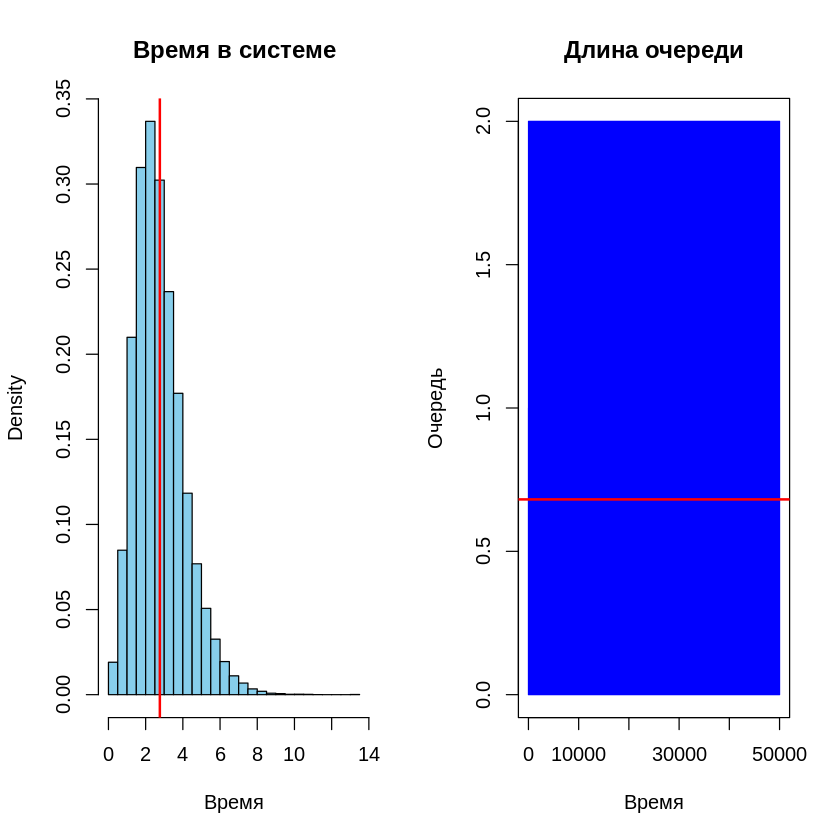

In [ ]:
par(mfrow = c(1, 2))
hist(departs - arrivals[1:n], breaks = 30, col = "skyblue",
     main = "Время в системе", xlab = "Время", prob = TRUE)
abline(v = W, col = "red", lwd = 2)

plot(time_log, queue_len_log, type = "s", col = "blue",
     main = "Длина очереди", xlab = "Время", ylab = "Очередь")
abline(h = Lq, col = "red", lwd = 2)

In [ ]:


library(simmer)

N <- 4
M <- 2
lambda <- 1.662623
mu <- 0.4242488
alpha <- 3 * lambda


r_erlang3 <- function() sum(rexp(3, rate = alpha))

traj <- trajectory() %>%
  seize("server", amount = 1) %>%
  timeout(function() rexp(1, mu)) %>%
  release("server", amount = 1)


env <- simmer("E3_M_4_2") %>%
  add_resource("server",
               capacity = N,
               queue_size = M) %>%
  add_generator("request",
                traj,
                r_erlang3)

set.seed(123)
env %>% run(until = 50000)

resources <- get_mon_resources(env)
arrivals <- get_mon_arrivals(env)

W_system <- mean(arrivals$end_time - arrivals$start_time)
W_queue <- mean(arrivals$end_time - arrivals$start_time - arrivals$activity_time)
L_system <- mean(resources$system)
L_queue <- mean(resources$queue)

total_arrivals <- nrow(arrivals)
lambda_eff <- total_arrivals / 50000
rejected <- sum(arrivals$activity_time == 0)
p_reject <- rejected / total_arrivals

cat("W (ср. время в системе)  =", round(W_system, 4), "\n")
cat("L (ср. число заявок)     =", round(L_system, 4), "\n")
cat("Wq (ср. время в очереди) =", round(W_queue, 4), "\n")
cat("Lq (ср. длина очереди)   =", round(L_queue, 4), "\n")
cat("λ_eff (пропускная способн.)=", round(lambda_eff, 4), "\n")
cat("P_отк (вероятность отказа)=", round(p_reject, 4), "\n")


simmer environment: E3_M_4_2 | now: 50000 | next: 50000.3130961616
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 2(4) | queue status: 0(2) }
{ Source: request | monitored: 1 | n_generated: 83362 }

W (ср. время в системе)  = 2.3873 
L (ср. число заявок)     = 3.8294 
Wq (ср. время в очереди) = 0.3556 
Lq (ср. длина очереди)   = 0.4621 
λ_eff (пропускная способн.)= 1.6672 
P_отк (вероятность отказа)= 0.139 


Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy.coords(x, y), type = type, ...):
“"metric" is not a graphical parameter”
Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy.coords(x, y), type = type, ...):
“"metric" is not a graphical par

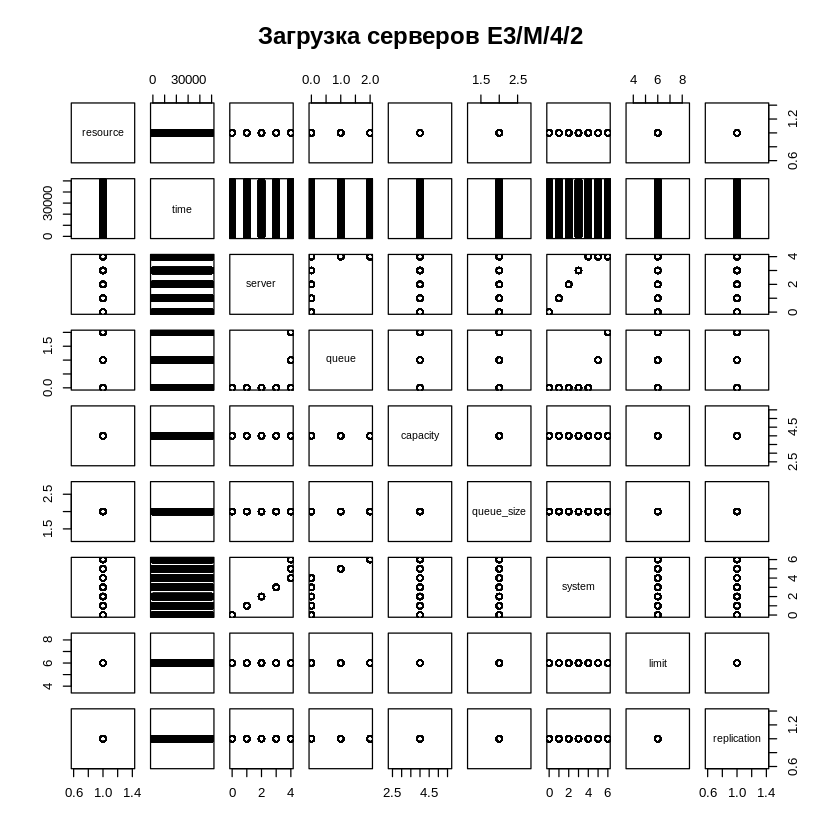

Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"metric" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"metric" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"metric" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"metric" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"metric" is not a graphical paramet

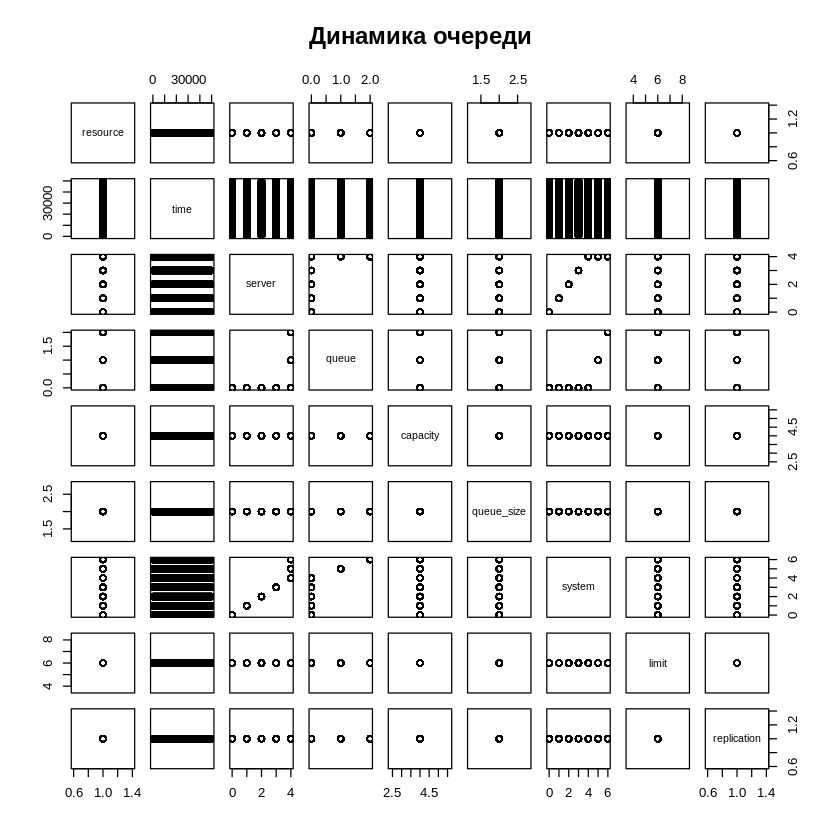

Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy.coords(x, y), type = type, ...):
“"metric" is not a graphical parameter”
Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy.coords(x, y), type = type, ...):
“"metric" is not a graphical par

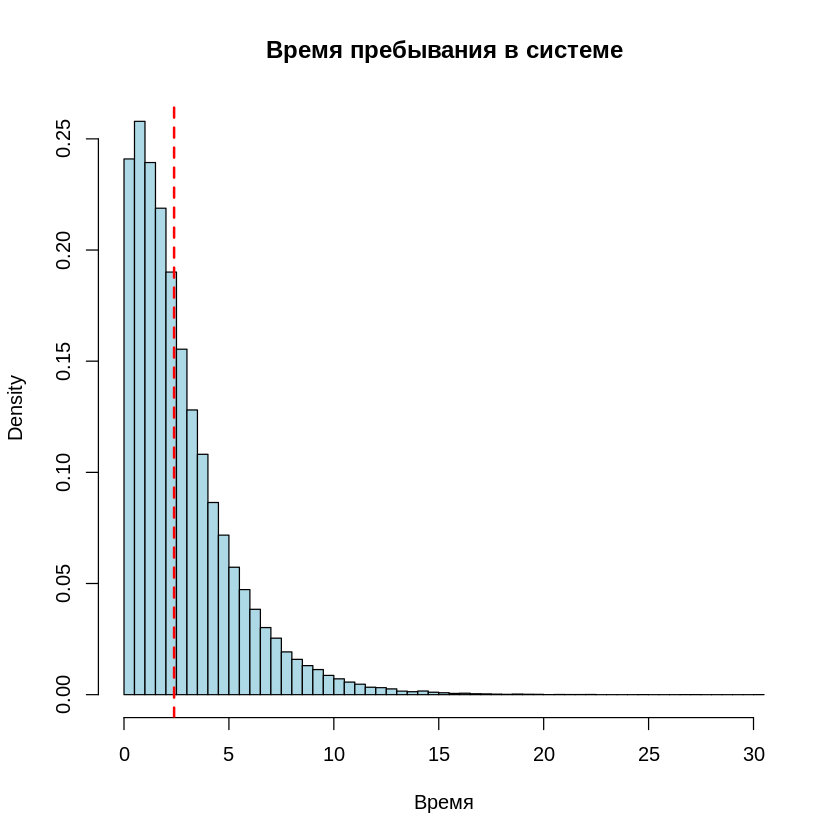

Warning message in plot.window(...):
“"metric" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"metric" is not a graphical parameter”
Warning message in title(...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"metric" is not a graphical parameter”


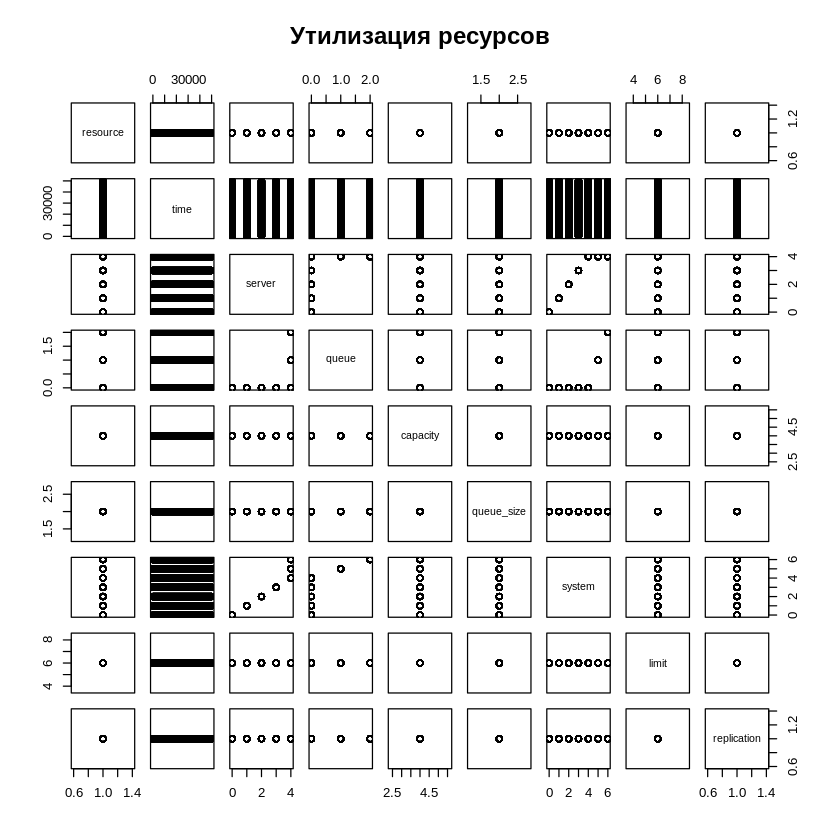

In [ ]:
plot(res, metric = "usage",
     main = "Загрузка серверов E3/M/4/2")

plot(res, metric = "queue",
     main = "Динамика очереди")

